# DAPO AIME pass@k plots

This notebook pulls selected DAPO runs from W&B project `ai2-llm/open_instruct_internal`, plots `eval/math_aime_2025/pass_at_1` over training steps, and plots final `eval/math_aime_2025/pass_at_k` curves for the initial eval and each training run. The initial point at `Step == 0` comes from run `k3kgf1up`.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import wandb

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
AIME_METRIC_PREFIX = "eval/math_aime_2025"
PASS_AT_1_KEY = f"{AIME_METRIC_PREFIX}/pass_at_1"
INITIAL_RUN_ID = "k3kgf1up"
INITIAL_RUN_NAME = "initial_eval"

RUNS = [
    {"run_id": "kfk9fxj5", "setting": "N=16, K=8", "N": 16, "K": 8},
    {"run_id": "dm59ak42", "setting": "N=8, K=16", "N": 8, "K": 16},
    {"run_id": "2i7owuys", "setting": "N=4, K=32", "N": 4, "K": 32},
    {"run_id": "os1kcy0m", "setting": "N=2, K=64", "N": 2, "K": 64},
]
RUN_IDS = [run["run_id"] for run in RUNS]
SETTING_ORDER = [run["setting"] for run in RUNS]

STEP_BIN = 100
MAX_STEP = 1000
REPO_OR_NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = (REPO_OR_NOTEBOOK_DIR if REPO_OR_NOTEBOOK_DIR.name == "notebooks" else REPO_OR_NOTEBOOK_DIR / "notebooks") / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Pull W&B runs

In [3]:
def normalized_step(step: int | float, *, bin_size: int = STEP_BIN) -> int:
    return int(round(float(step) / bin_size) * bin_size)


def load_run_metadata(run_specs: list[dict[str, object]]) -> tuple[pd.DataFrame, dict[str, wandb.apis.public.Run]]:
    rows = []
    run_by_id = {}
    for spec in run_specs:
        run = api.run(f"{PROJECT_PATH}/{spec['run_id']}")
        run_by_id[run.id] = run
        rows.append(
            {
                **spec,
                "run_name": run.name,
                "state": run.state,
                "created_at": run.created_at,
                "url": run.url,
            }
        )

    initial_run = api.run(f"{PROJECT_PATH}/{INITIAL_RUN_ID}")
    run_by_id[INITIAL_RUN_ID] = initial_run
    runs_df = pd.DataFrame(rows)
    runs_df["setting"] = pd.Categorical(runs_df["setting"], categories=SETTING_ORDER, ordered=True)
    return runs_df.sort_values("setting").reset_index(drop=True), run_by_id


def download_pass_at_1_history(run: wandb.apis.public.Run, *, setting: str, include_initial: bool = False) -> pd.DataFrame:
    rows = []
    for row in run.scan_history(keys=["_step", PASS_AT_1_KEY], page_size=1000):
        value = row.get(PASS_AT_1_KEY)
        if value is None:
            continue
        raw_step = int(row.get("_step", row.get("Step", 0)))
        rows.append(
            {
                "run_id": run.id,
                "run_name": INITIAL_RUN_NAME if include_initial else run.name,
                "setting": setting,
                "raw_step": raw_step,
                "Step": 0 if include_initial else normalized_step(raw_step),
                "metric_key": PASS_AT_1_KEY,
                "value": float(value),
            }
        )
    history = pd.DataFrame(rows)
    if history.empty:
        return history
    return history.sort_values(["Step", "raw_step"]).groupby(["run_id", "run_name", "setting", "Step", "metric_key"], as_index=False).agg(
        value=("value", "last"),
        raw_step=("raw_step", "last"),
    )


def collect_pass_at_1_histories(runs_df: pd.DataFrame, run_by_id: dict[str, wandb.apis.public.Run]) -> pd.DataFrame:
    histories = []
    initial_run = run_by_id[INITIAL_RUN_ID]
    for run_row in runs_df.itertuples(index=False):
        history = download_pass_at_1_history(run_by_id[run_row.run_id], setting=run_row.setting)
        print(f"{run_row.run_id}: downloaded {len(history):,} pass@1 rows")
        histories.append(history)

        initial_history = download_pass_at_1_history(initial_run, setting=run_row.setting, include_initial=True)
        if not initial_history.empty:
            histories.append(initial_history.tail(1))

    history_df = pd.concat([history for history in histories if not history.empty], ignore_index=True)
    history_df = history_df[(history_df["Step"] >= 0) & (history_df["Step"] <= MAX_STEP)].copy()
    history_df["setting"] = pd.Categorical(history_df["setting"], categories=SETTING_ORDER, ordered=True)
    return history_df.sort_values(["setting", "Step", "run_id"]).reset_index(drop=True)


def pass_at_k_summary_rows(run: wandb.apis.public.Run, *, label: str, setting_order: list[str]) -> list[dict[str, object]]:
    rows = []
    for key, value in run.summary.items():
        match = re.fullmatch(rf"{re.escape(AIME_METRIC_PREFIX)}/pass_at_(\d+)", key)
        if match is None or value is None:
            continue
        rows.append({"run_id": run.id, "setting": label, "k": int(match.group(1)), "value": float(value), "metric_key": key})
    return sorted(rows, key=lambda row: row["k"])


def collect_final_pass_at_k(runs_df: pd.DataFrame, run_by_id: dict[str, wandb.apis.public.Run]) -> pd.DataFrame:
    rows = pass_at_k_summary_rows(run_by_id[INITIAL_RUN_ID], label=INITIAL_RUN_NAME, setting_order=SETTING_ORDER)
    for run_row in runs_df.itertuples(index=False):
        rows.extend(pass_at_k_summary_rows(run_by_id[run_row.run_id], label=run_row.setting, setting_order=SETTING_ORDER))

    pass_at_k_df = pd.DataFrame(rows)
    if pass_at_k_df.empty:
        raise ValueError("No final pass@k summary metrics were found.")
    label_order = [INITIAL_RUN_NAME, *SETTING_ORDER]
    pass_at_k_df["setting"] = pd.Categorical(pass_at_k_df["setting"], categories=label_order, ordered=True)
    return pass_at_k_df.sort_values(["setting", "k"]).reset_index(drop=True)

In [4]:
runs_df, run_by_id = load_run_metadata(RUNS)
pass_at_1_df = collect_pass_at_1_histories(runs_df, run_by_id)
pass_at_k_df = collect_final_pass_at_k(runs_df, run_by_id)

display(runs_df)
display(pass_at_1_df.head())
display(pass_at_k_df)

kfk9fxj5: downloaded 10 pass@1 rows


dm59ak42: downloaded 10 pass@1 rows


2i7owuys: downloaded 10 pass@1 rows


os1kcy0m: downloaded 9 pass@1 rows


,run_id,setting,N,K,run_name,state,created_at,url
0,kfk9fxj5,"N=16, K=8",16,8,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,finished,2026-05-04T22:37:20Z,https://wandb.ai/ai2-llm/open_instruct_interna...
1,dm59ak42,"N=8, K=16",8,16,qwen3_4b_base_dapo_baseline_async4__1__1777915407,finished,2026-05-04T17:23:30Z,https://wandb.ai/ai2-llm/open_instruct_interna...
2,2i7owuys,"N=4, K=32",4,32,qwen3_4b_base_dapo_baseline_async4_n4_k32__1__...,finished,2026-05-04T22:44:48Z,https://wandb.ai/ai2-llm/open_instruct_interna...
3,os1kcy0m,"N=2, K=64",2,64,qwen3_4b_base_dapo_baseline_async4_n2_k64__1__...,finished,2026-05-05T01:36:15Z,https://wandb.ai/ai2-llm/open_instruct_interna...


,run_id,run_name,setting,Step,metric_key,value,raw_step
0,k3kgf1up,initial_eval,"N=16, K=8",0,eval/math_aime_2025/pass_at_1,0.051618,1
1,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",100,eval/math_aime_2025/pass_at_1,0.085100,105
2,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",200,eval/math_aime_2025/pass_at_1,0.132254,204
3,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",300,eval/math_aime_2025/pass_at_1,0.133929,303
4,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",400,eval/math_aime_2025/pass_at_1,0.157227,402


,run_id,setting,k,value,metric_key
0,k3kgf1up,initial_eval,1,0.051618,eval/math_aime_2025/pass_at_1
1,k3kgf1up,initial_eval,2,0.090915,eval/math_aime_2025/pass_at_2
2,k3kgf1up,initial_eval,4,0.144381,eval/math_aime_2025/pass_at_4
3,k3kgf1up,initial_eval,8,0.199415,eval/math_aime_2025/pass_at_8
4,k3kgf1up,initial_eval,16,0.247789,eval/math_aime_2025/pass_at_16
5,k3kgf1up,initial_eval,32,0.294643,eval/math_aime_2025/pass_at_32
6,kfk9fxj5,"N=16, K=8",1,0.190290,eval/math_aime_2025/pass_at_1
7,kfk9fxj5,"N=16, K=8",2,0.230541,eval/math_aime_2025/pass_at_2
8,kfk9fxj5,"N=16, K=8",4,0.277895,eval/math_aime_2025/pass_at_4
9,kfk9fxj5,"N=16, K=8",8,0.338008,eval/math_aime_2025/pass_at_8


## Plot eval/math_aime_2025/pass_at_1

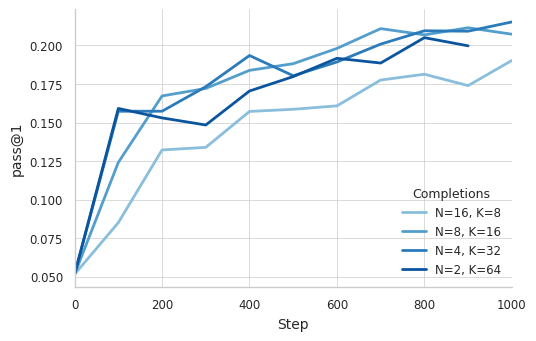

In [5]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(5.25, 3.3), constrained_layout=True)
blue_palette = dict(zip(SETTING_ORDER, sns.color_palette("Blues", n_colors=len(SETTING_ORDER) + 2)[2:]))

sns.lineplot(
    data=pass_at_1_df,
    x="Step",
    y="value",
    hue="setting",
    hue_order=SETTING_ORDER,
    palette=blue_palette,
    estimator=None,
    ax=ax,
)

ax.set_xlabel("Step")
ax.set_ylabel("pass@1")
ax.set_xlim(0, MAX_STEP)
ax.set_xticks(range(0, MAX_STEP + STEP_BIN, 200))
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Completions", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1.pdf", bbox_inches="tight")

## Plot final eval/math_aime_2025/pass_at_k

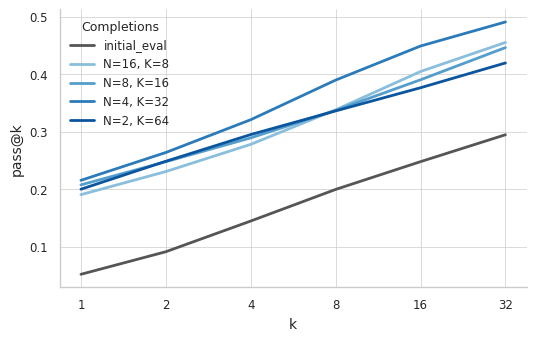

In [6]:
fig, ax = plt.subplots(figsize=(5.25, 3.3), constrained_layout=True)
label_order = [INITIAL_RUN_NAME, *SETTING_ORDER]
palette = {INITIAL_RUN_NAME: "#555555", **blue_palette}

sns.lineplot(
    data=pass_at_k_df,
    x="k",
    y="value",
    hue="setting",
    hue_order=label_order,
    palette=palette,
    estimator=None,
    ax=ax,
)

ks = sorted(pass_at_k_df["k"].unique())
ax.set_xlabel("k")
ax.set_ylabel("pass@k")
ax.set_xscale("log", base=2)
ax.set_xticks(ks)
ax.set_xticklabels([str(k) for k in ks])
ax.legend(title="Completions", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "dapo_aime_2025_final_pass_at_k.pdf", bbox_inches="tight")